In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [30]:
df = pd.read_csv(r'C:\Users\kunwa\PycharmProjects\ML\logistic Reg\logistic regression dataset-Social_Network_Ads.csv')

In [31]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [32]:
df.info

<bound method DataFrame.info of       User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]>

In [33]:
df.drop(["User ID"], inplace=True, axis = 1)

In [34]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop("Purchased", axis = 1), df["Purchased"], test_size = 0.2, random_state = 42)

In [35]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output = False, drop = "first")
x_train_ohe = ohe.fit_transform(x_train[["Gender"]])
x_test_ohe = ohe.transform(x_test[["Gender"]])


In [36]:
x_train.drop("Gender", axis = 1, inplace = True)
x_test.drop("Gender", axis = 1, inplace = True)
x_train["Gender"] = x_train_ohe


In [37]:

x_test["Gender"] = x_test_ohe

In [38]:
x_train

,Age,EstimatedSalary,Gender
3,27,57000,0.0
18,46,28000,1.0
202,39,134000,0.0
250,44,39000,0.0
274,57,26000,0.0
...,...,...,...
71,24,27000,0.0
106,26,35000,0.0
270,43,133000,0.0
348,39,77000,1.0


In [39]:
x_train.describe()


,Age,EstimatedSalary,Gender
count,320.000000,320.00000,320.000000
mean,37.871875,70281.25000,0.500000
std,10.207525,34430.55286,0.500783
min,18.000000,15000.00000,0.000000
25%,30.000000,43000.00000,0.000000
50%,37.000000,71000.00000,0.500000
75%,45.000000,88000.00000,1.000000
max,60.000000,150000.00000,1.000000


In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [43]:
x_train = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_test = pd.DataFrame(x_test_scaled, columns = x_test.columns)

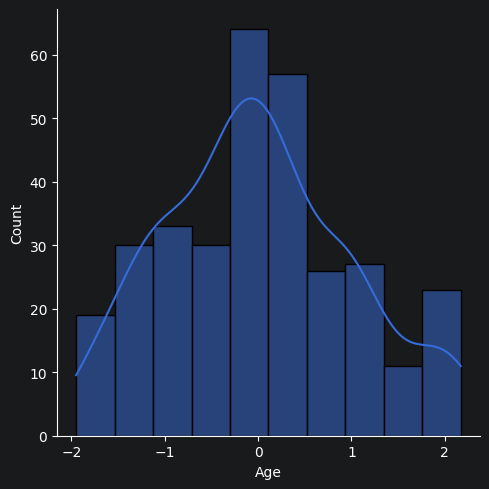

In [45]:
sns.displot(x_train["Age"], kde = True)


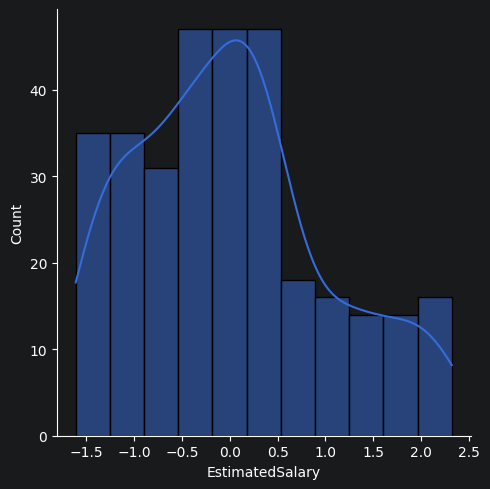

In [46]:
sns.displot(x_train["EstimatedSalary"], kde = True)

<Axes: ylabel='Age'>

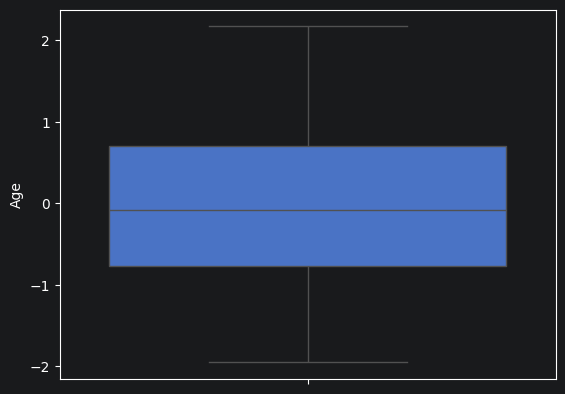

In [47]:
sns.boxplot(x_train["Age"])

<Axes: ylabel='EstimatedSalary'>

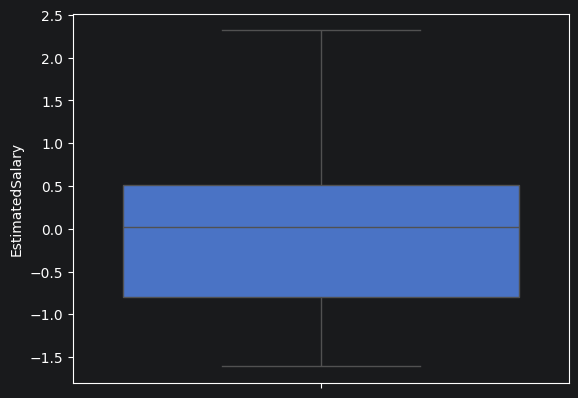

In [48]:
sns.boxplot(x_train["EstimatedSalary"])

In [49]:
from sklearn.preprocessing import PowerTransformer

In [50]:
pt = PowerTransformer(method= "yeo-johnson")
x_train_pt = pt.fit_transform(x_train)
x_test_pt = pt.transform(x_test)


In [54]:
x_train = pd.DataFrame(x_train_pt, columns = x_train.columns)
x_test = pd.DataFrame(x_test_pt, columns = x_test.columns)

In [55]:
x_train

,Age,EstimatedSalary,Gender
0,-1.090639,-0.299075,-1.0
1,0.821084,-1.344331,1.0
2,0.173330,1.667838,-1.0
3,0.641383,-0.928903,-1.0
4,1.756878,-1.422103,-1.0
...,...,...,...
315,-1.431375,-1.383134,-1.0
316,-1.203321,-1.077489,-1.0
317,0.550087,1.646851,-1.0
318,0.173330,0.311781,1.0


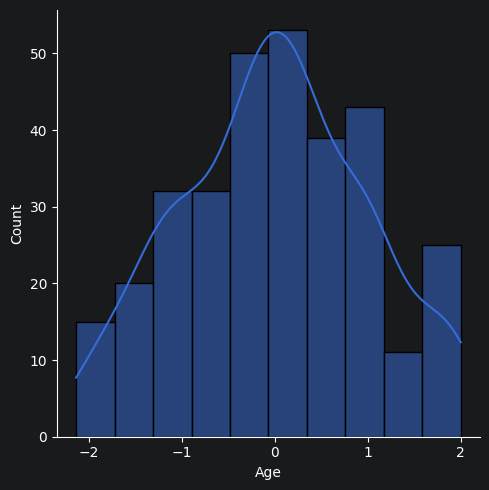

In [56]:
sns.displot(x_train["Age"], kde = True)

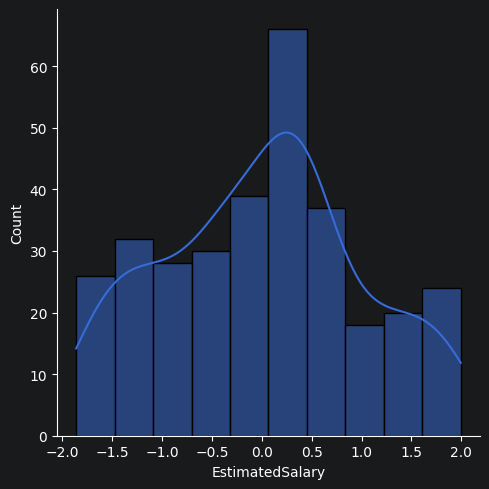

In [57]:
sns.displot(x_train["EstimatedSalary"], kde = True)

In [59]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(x_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [62]:
y_pred = lg.predict(x_test)

In [64]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.875


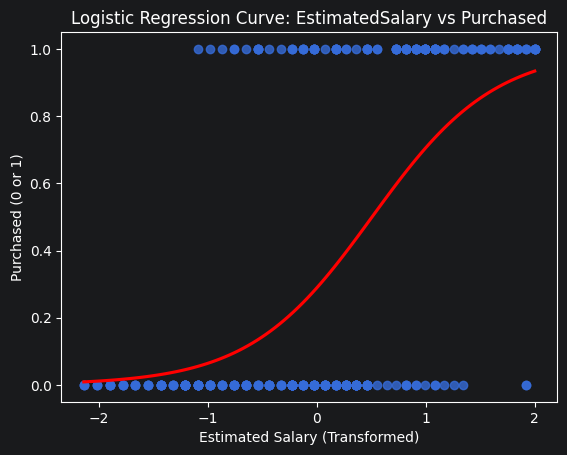

In [84]:

# sns.regplot with logistic=True automatically fits and plots the logistic curve
sns.regplot(
    x=x_train["Age"],
    y=y_train,
    logistic=True,
    ci=None,
    line_kws={'color': 'red'}
)

plt.title("Logistic Regression Curve: EstimatedSalary vs Purchased")
plt.xlabel("Estimated Salary (Transformed)")
plt.ylabel("Purchased (0 or 1)")
plt.show()